In [7]:
import pytorch3d.structures
import pytorch3d.io
import pytorch3d.renderer
import pytorch3d.renderer.cameras
import torch
import numpy
import imageio
from matplotlib import pyplot as plt
import pickle
from pytorch3d.implicitron.models.model_dbir import get_rgbd_point_cloud


In [8]:
file = open("data/rgbd_data.pkl", "rb")
obj = pickle.load(file)
file.close()

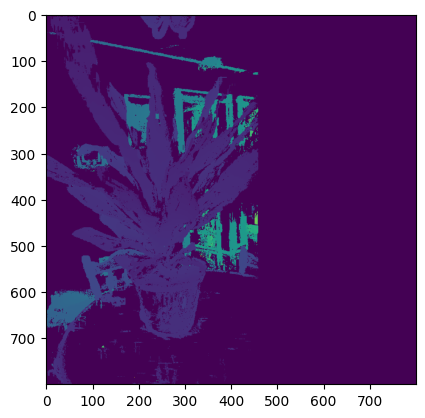

In [9]:
cameras1 = obj['cameras2']
depth = torch.Tensor(obj['depth2'] / (obj['depth2'].max() - obj['depth2'].min()) )
points1 = cameras1.unproject_points(depth, world_coordinates=True)
plt.imshow(depth)

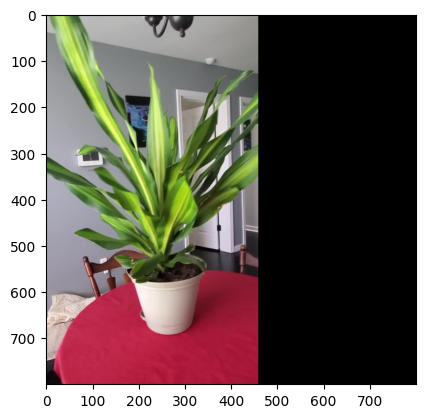

In [10]:
plt.plot(figsize=(10, 10))

plt.imshow(obj['rgb2'])

In [11]:
rgb = torch.Tensor( numpy.ones_like(points1.numpy()) )
pointcloud = pytorch3d.structures.Pointclouds(points=[points1], features=[rgb])


In [12]:
renderer = pytorch3d.renderer.PointsRenderer(
    rasterizer = pytorch3d.renderer.PointsRasterizer(
        cameras=cameras1
    ),
    compositor = pytorch3d.renderer.AlphaCompositor()
)

In [13]:
rend = renderer(pointcloud, cameras=cameras1)

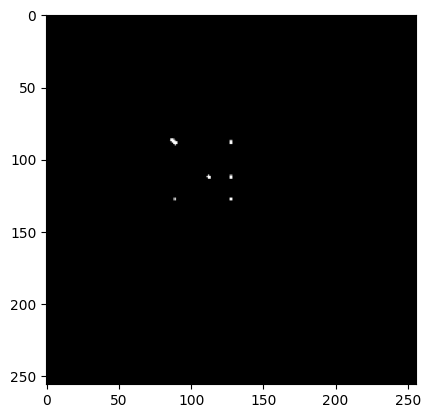

In [14]:
plt.plot(figsize=(10,10))
plt.imshow(rend[0, ..., :3].numpy())

In [15]:
obj

{'rgb1': array([[[0.81960785, 0.8039216 , 0.80784315],
         [0.81960785, 0.8039216 , 0.80784315],
         [0.8187211 , 0.8030349 , 0.8069564 ],
         ...,
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ]],
 
        [[0.81960785, 0.8039216 , 0.80784315],
         [0.81960785, 0.8039215 , 0.80784315],
         [0.8182827 , 0.80259645, 0.806518  ],
         ...,
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ]],
 
        [[0.81828433, 0.802598  , 0.8065196 ],
         [0.8196078 , 0.8039216 , 0.80784315],
         [0.8174043 , 0.80171794, 0.80563956],
         ...,
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ]],
 
        ...,
 
        [[0.6610104 , 0.20610838, 0.2806182 ],
         [0.6588363 , 0.20393431,

In [16]:
points1.shape, rgb.shape

(torch.Size([800, 3]), torch.Size([800, 3]))

In [17]:
print(depth.min())

tensor(0.)


In [18]:
points1.shape, depth.shape

(torch.Size([800, 3]), torch.Size([800, 800]))

In [19]:
pointcloud.points_list()[0].shape

torch.Size([800, 3])

In [20]:
!pip install omegaconf

## Point cloud for first image

In [21]:
rgb_restacked = torch.Tensor([obj['rgb1'][:, :, 0], obj['rgb1'][:, :, 1], obj['rgb1'][:, :, 2]])

batch_cam = obj['cameras1']
batch_img_rgb = rgb_restacked.unsqueeze(0)
batch_depth = torch.Tensor(obj['depth1']).unsqueeze(0).unsqueeze(0)

point_cloud_1 = get_rgbd_point_cloud(batch_cam, batch_img_rgb, batch_depth)

/tmp/ipykernel_19185/1982517119.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:230.)
  rgb_restacked = torch.Tensor([obj['rgb1'][:, :, 0], obj['rgb1'][:, :, 1], obj['rgb1'][:, :, 2]])


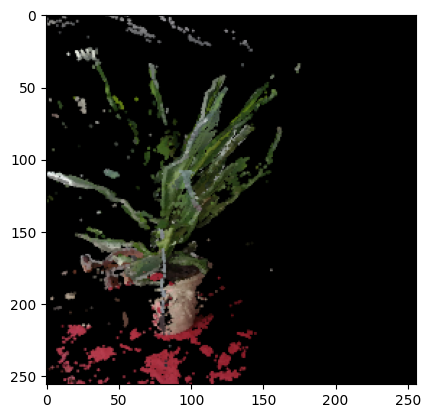

In [22]:
rend = renderer(point_cloud_1, cameras=obj['cameras2'])
plt.plot(figsize=(10, 10))
plt.imshow(rend.squeeze(0))

## Point cloud for second image

In [23]:
# Restack image tensor to 3,H,W
obj['rgb2']
rgb_restacked = torch.Tensor([obj['rgb2'][:, :, 0], obj['rgb2'][:, :, 1], obj['rgb2'][:, :, 2]])

batch_cam = obj['cameras2']
batch_img_rgb = rgb_restacked.unsqueeze(0)
batch_depth = torch.Tensor(obj['depth2']).unsqueeze(0).unsqueeze(0)

point_cloud_2 = get_rgbd_point_cloud(batch_cam, batch_img_rgb, batch_depth)

In [24]:
rend = renderer(point_cloud_2, cameras=obj['cameras2'])

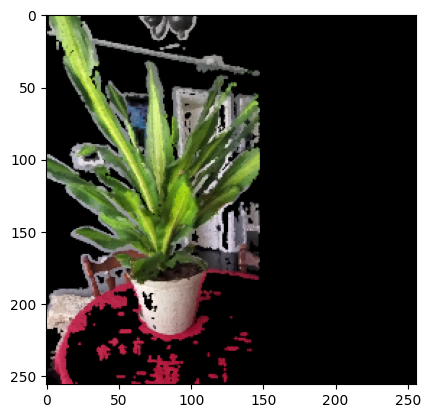

In [25]:
plt.plot(figsize=(10, 10))
plt.imshow(rend.squeeze(0))

## Joined pointclouds

In [26]:
pc_combined = pytorch3d.structures.join_pointclouds_as_scene([point_cloud_1, point_cloud_2])
pc_combined

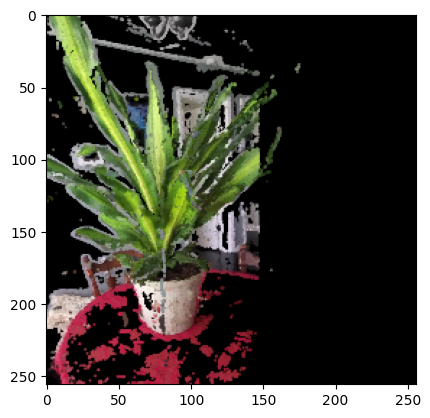

In [27]:
rend = renderer(pc_combined, cameras=obj['cameras2'])
plt.plot(figsize=(10, 10))
plt.imshow(rend.squeeze(0))

## Render GIFs of point clouds

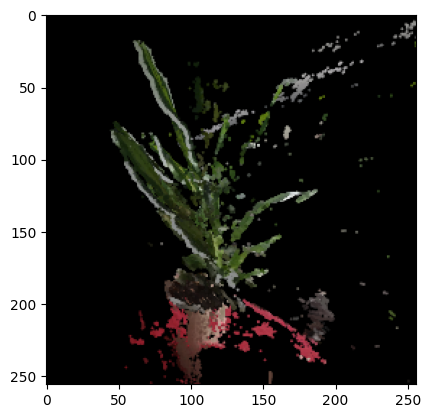

In [34]:
### Point cloud 1

R, T = pytorch3d.renderer.look_at_view_transform(dist=4, elev=0.0, azim=0.0, up=((0, -1, 0),))
plt.plot(figsize=(10, 10))
plt.imshow(renderer(point_cloud_1, cameras=pytorch3d.renderer.PerspectiveCameras(R=R, T=T)).squeeze(0))

In [37]:
frames = []

for azim in range(0, 360, 20):
    R, T = pytorch3d.renderer.look_at_view_transform(dist=4, elev=0.0, azim=azim, up=((0, -1, 0),))
    # plt.plot(figsize=(10, 10))
    frame = renderer(point_cloud_1, cameras=pytorch3d.renderer.PerspectiveCameras(R=R, T=T)).squeeze(0)
    frame = (frame.numpy() * 255).astype(numpy.uint8)
    frames.append(frame)
    

In [38]:
imageio.mimwrite("spinning_cloudpoint_1.gif", frames, loop=0)

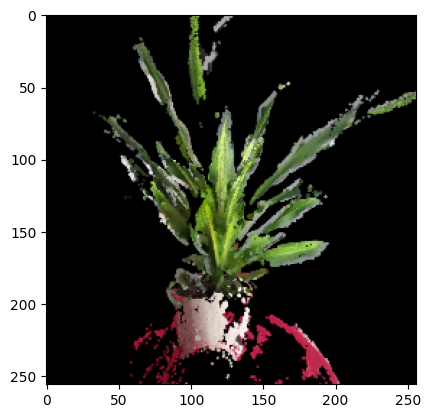

In [39]:
# For point cloud 2

R, T = pytorch3d.renderer.look_at_view_transform(dist=4, elev=0.0, azim=0.0, up=((0, -1, 0),))
plt.plot(figsize=(10, 10))
plt.imshow(renderer(point_cloud_2, cameras=pytorch3d.renderer.PerspectiveCameras(R=R, T=T)).squeeze(0))

In [40]:
frames = []

for azim in range(0, 360, 20):
    R, T = pytorch3d.renderer.look_at_view_transform(dist=4, elev=0.0, azim=azim, up=((0, -1, 0),))
    # plt.plot(figsize=(10, 10))
    frame = renderer(point_cloud_2, cameras=pytorch3d.renderer.PerspectiveCameras(R=R, T=T)).squeeze(0)
    frame = (frame.numpy() * 255).astype(numpy.uint8)
    frames.append(frame)
    

In [41]:
imageio.mimwrite("spinning_cloudpoint_2.gif", frames, loop=0)

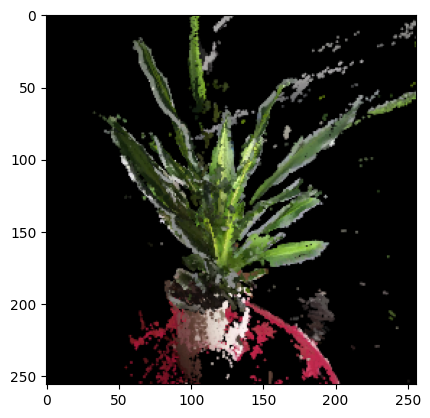

In [42]:
# For combined point cloud

R, T = pytorch3d.renderer.look_at_view_transform(dist=4, elev=0.0, azim=0.0, up=((0, -1, 0),))
plt.plot(figsize=(10, 10))
plt.imshow(renderer(pc_combined, cameras=pytorch3d.renderer.PerspectiveCameras(R=R, T=T)).squeeze(0))

In [43]:
frames = []

for azim in range(0, 360, 20):
    R, T = pytorch3d.renderer.look_at_view_transform(dist=4, elev=0.0, azim=azim, up=((0, -1, 0),))
    # plt.plot(figsize=(10, 10))
    frame = renderer(pc_combined, cameras=pytorch3d.renderer.PerspectiveCameras(R=R, T=T)).squeeze(0)
    frame = (frame.numpy() * 255).astype(numpy.uint8)
    frames.append(frame)
    

In [45]:
imageio.mimsave("spinning_cloudpoint_combined.gif", frames, loop=0)